In [8]:
# =============================
# 1. Imports
# =============================
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import sys
import os

# # remonter d’un niveau (ou plus selon ton arborescence)
# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# sys.path.append(project_root)
from models.mil_max_pooling import MILMaxPooling
import models
from datasets.her2_datasets import HER2Dataset

In [10]:
# =============================
# 2. Load Model
# =============================
MODEL_PATH = "C:/Users/manon/Documents/pathology_MIL/src/multirun/2026-04-10/14-33-22/2/model_final_1_0.0001.pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.serialization.add_safe_globals([models.mil_max_pooling.MILMaxPooling])
model = torch.load(MODEL_PATH, map_location=DEVICE,weights_only=False)
model.eval()


print("Model loaded on:", DEVICE)

Model loaded on: cuda


In [11]:
# =============================
# 3. Load Dataset
# =============================
test_df = pd.read_csv('C:/Users/manon/Documents/pathology_MIL/data/splits/test.csv')  
test_dataset = HER2Dataset(test_df, embeddings_dir='C:/Users/manon/Documents/pathology_MIL/data/HER2MATCH_224_UNI2_embeds/HE/test')
dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)


In [12]:
# =============================
# 4. Inference
# =============================
all_preds = []
all_labels = []
raw_outputs = []

with torch.no_grad():
    for bags, labels in dataloader:
        bags = bags[0].to(DEVICE).float()
        labels = labels.to(DEVICE)

        outputs = model(bags)

        print(outputs.shape)

        # Scalar ourput (batch,)
        if outputs.ndim == 0 or outputs.ndim == 1:
            preds = (torch.sigmoid(outputs) > 0.5).long()

        # (batch, 1)
        elif outputs.shape[-1] == 1:
            preds = (torch.sigmoid(outputs.squeeze(-1)) > 0.5).long()

        # Several class (batch, num_classes)
        else:
            preds = torch.argmax(outputs, dim=1)
        bag_preds_overall = np.average([preds.cpu().numpy().flatten()])

        # Convertir en 0/1 si nécessaire
        raw_outputs.append(outputs)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

torch.Size([])
torch.Size([])
torch.Size([])
torch.Size([])
torch.Size([])


In [13]:
all_preds
raw_outputs

[tensor(2.2865, device='cuda:0'),
 tensor(1.0574, device='cuda:0'),
 tensor(0.5094, device='cuda:0'),
 tensor(-0.0148, device='cuda:0'),
 tensor(0.1720, device='cuda:0')]

Accuracy: 0.2000
Precision: 0.2500
Recall: 0.5000


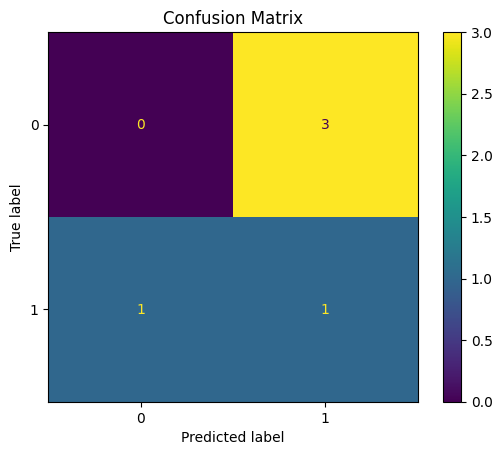

In [14]:
# =============================
# 5. Metrics
# =============================
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# =============================
# 6. Confusion Matrix
# =============================
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# =============================
# 7. Save Results (optional)
# =============================
results_df = pd.DataFrame({
    "y_true": all_labels,
    "y_pred": all_preds
})

results_df.to_csv("evaluation_results.csv", index=False)
print("Results saved to evaluation_results.csv")
